# 05 — Operating Condition Identification

**Notebook focus:** answer Q9–Q10 by discovering recurring surface-card regimes,
then analysing their time structure and offering physical hypotheses for the
changes they may reflect downhole.

**Goals**
- **Q9**: identify surface-card operating regimes via unsupervised clustering; justify the algorithmic choice.
- **Q10**: characterise the time structure of the regimes and propose physical hypotheses. Prediction is treated only as a bonus check.

## Contents
1. Setup and trusted card extraction
2. Build the six-feature clustering space
3. Choose a useful KMeans taxonomy
4. Cross-check with HDBSCAN
5. Interpret the clusters with medoid cards
6. Validate nb04's era references against the Q9 taxonomy
7. Plot the 21-day regime timeline
8. Collapse card labels into episodes
9. Analyse the transition matrix
10. Check timer-boundary / hour / day coupling
11. Bonus prediction check
12. Final Q9/Q10 summary


## 1. Setup and trusted card extraction

**Takeaway:** nb05 starts from the same trusted card set as nb04, so both notebooks speak the same card language.


Same extraction pipeline as nb04.  Layer-1 trust filter (stroke ±10 %, gap_frac < P95) applied before any clustering.

In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.cm as cm
from sklearn.metrics import adjusted_rand_score, silhouette_score

from well_analysis.data import load_test_data
from well_analysis.signal import check_even_sampling, transient_mask
from well_analysis.signal.integration import integrate_acceleration, estimate_gravity_offset
from well_analysis.detection import detect_well_state, classify_controller_mode, cluster_segments_by_duration
from well_analysis.analysis.dynamometer import estimate_pump_frequency
from well_analysis.analysis.clustering import (
    FEATURE_NAMES,
    cluster_operating_conditions,
    cluster_with_hdbscan,
    extract_card_features,
    episodes_from_labels,
    reduce_for_viz,
    transition_matrix,
)
from well_analysis.analysis.q8 import (
    build_card_metric_frame,
    build_trusted_subset,
    extract_cards_with_metrics,
)
from well_analysis.analysis.q9 import (
    build_trusted_cluster_frame,
    episode_statistics,
    evaluate_bonus_prediction,
    evaluate_kmeans_grid,
    medoid_index,
    regime_mix_diagnostics,
    summarize_cluster_feature_means,
    transition_entropy_bits,
    validate_nb04_references_against_q9,
)

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

df = load_test_data()
_, fs = check_even_sampling(df['Timestamp'])
accel = df['Acceleration'].values
load = df['Load'].values
is_running = detect_well_state(accel, fs=fs)
g_offset = estimate_gravity_offset(accel, is_running)
_, position = integrate_acceleration(accel, fs=fs, gravity_offset=g_offset)
pump_freq = estimate_pump_frequency(accel[is_running], fs=fs)
valid_mask = transient_mask(is_running, fs=fs, hp_cutoff=0.04)

# Reuse the same extraction logic as nb04 so Q8/Q9/Q10 share the same cards.
segs = classify_controller_mode(df['Timestamp'], is_running)
seg_c, _ = cluster_segments_by_duration(segs)
timer_on = seg_c[seg_c['cluster_label'] == 'timer_on'].reset_index(drop=True)
ts_arr = df['Timestamp'].values.astype('datetime64[ns]')

all_cards = extract_cards_with_metrics(
    timer_on=timer_on,
    timestamps_ns=ts_arr,
    position=position,
    load=load,
    fs=fs,
    pump_freq=pump_freq,
    valid_mask=valid_mask,
    use_card_timestamp=True,
)
dm = build_card_metric_frame(all_cards)
print(f'Extracted {len(all_cards):,} cards from {len(timer_on)} timer_on segments.')

stroke_dev, gap_thresh, trusted_mask, trusted_idx = build_trusted_subset(dm)
trusted_cards = [all_cards[i] for i in trusted_idx]
print(f'Trusted: {len(trusted_cards):,} / {len(all_cards):,} ({100*trusted_mask.mean():.1f} %)')


Extracted 18,133 cards from 219 timer_on segments.
Trusted: 17,219 / 18,133 (95.0 %)


## 2. Feature engineering (Q9)

**Takeaway:** Q9 uses a small, interpretable feature set so each cluster can still be explained physically.


Clustering operates on a **6-dim feature per card**.  All features are physically interpretable — we deliberately avoid hand-crafted combinations that would be hard to explain.

| Feature | Physical meaning |
|---|---|
| `area` | Net work per stroke (shoelace) |
| `p10_load` | Lower plateau — standing-valve side |
| `p90_load` | Upper plateau — travelling-valve side |
| `asym_tilt` | Polygon-centroid horizontal offset / stroke — geometric asymmetry |
| `upstroke_heaviness` | (mean load upstroke − mean load downstroke) / sum — temporal asymmetry |
| `load_median` | Baseline load; catches shape-preserving shifts (nb04 Family B signature) |

**Intentionally excluded:**
- `stroke` — trusted subset constrains it to ±10 % of median; `StandardScaler` would inflate the tiny residual variance and dominate the feature space.
- `load_range` — colinear with `p90 − p10`.
- `gap_frac` — QC metric, not physics; would leak the trust filter back into the clusters.

In [2]:
X = extract_card_features(trusted_cards)
print('Feature matrix shape:', X.shape)
print('Feature names       :', FEATURE_NAMES)
print()
print(pd.DataFrame(X, columns=FEATURE_NAMES).describe().round(3).T[['mean','std','25%','50%','75%']])


Feature matrix shape: (17219, 6)
Feature names       : ['area', 'p10_load', 'p90_load', 'asym_tilt', 'upstroke_heaviness', 'load_median']

                         mean       std        25%        50%        75%
area                 5639.109  1132.492   5793.928   6000.563   6166.924
p10_load            10564.273   232.764  10434.051  10534.292  10626.400
p90_load            19043.919   141.705  18939.361  19028.578  19148.576
asym_tilt              -0.013     0.047     -0.005      0.000      0.006
upstroke_heaviness      0.151     0.023      0.155      0.157      0.159
load_median         15424.143   738.510  15077.853  15227.985  15388.714


## 3. KMeans — interpretable fixed-k baseline (Q9)

**Takeaway:** KMeans provides the main working taxonomy, but we choose `k=3` as a useful partition rather than pretending the data uniquely demands three clusters.


KMeans partitions the feature space into `k` Voronoi cells centred on iteratively-refined centroids.  It is:

- **Interpretable** — each cluster has an average-card centroid we can plot.
- **Fast and deterministic** with random-state fixed.
- **Dependent on k** — we sweep `k ∈ {2..8}` and pick by joint argmax of silhouette and (negated) Davies–Bouldin score.

Limitations: assumes roughly isotropic, equal-density clusters.  If real regimes have very different sizes or shapes, HDBSCAN (§4) should disagree — which itself is useful information.

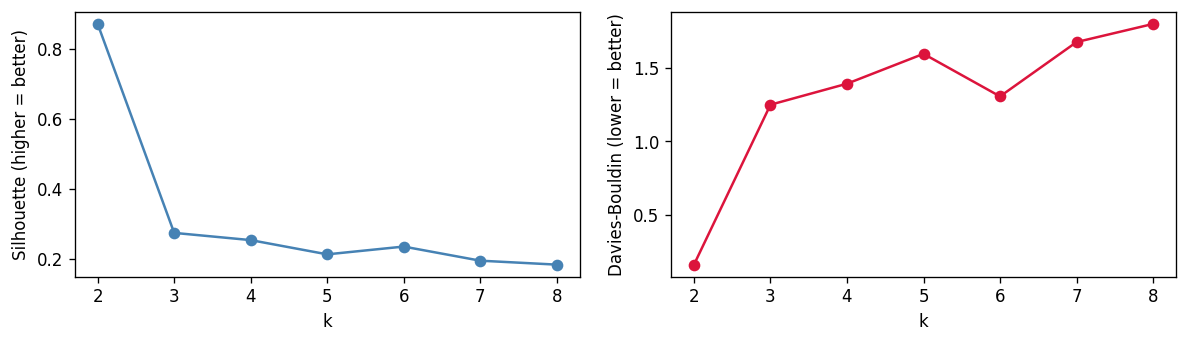

Silhouette per k  : {2: 0.871, 3: 0.275, 4: 0.254, 5: 0.213, 6: 0.236, 7: 0.195, 8: 0.184}
Davies-Bouldin    : {2: 0.164, 3: 1.25, 4: 1.392, 5: 1.595, 6: 1.306, 7: 1.675, 8: 1.798}
Best k (silhouette max within k in {3..6}): 3


In [3]:
# Keep the model-selection logic visible: scan k, then choose the best silhouette inside the interpretable band 3..6.
k_eval = evaluate_kmeans_grid(X, ks=range(2, 9), interpretable_ks=[3, 4, 5, 6])
ks = k_eval['ks']
sil = k_eval['silhouette']
db = k_eval['davies_bouldin']
best_k = k_eval['best_k']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3))
ax1.plot(ks, sil, 'o-', color='steelblue')
ax1.set_xlabel('k')
ax1.set_ylabel('Silhouette (higher = better)')
ax2.plot(ks, db, 'o-', color='crimson')
ax2.set_xlabel('k')
ax2.set_ylabel('Davies-Bouldin (lower = better)')
plt.tight_layout(); plt.show()

print(f'Silhouette per k  : {dict(zip(ks, [round(s,3) for s in sil]))}')
print(f'Davies-Bouldin    : {dict(zip(ks, [round(d,3) for d in db]))}')
print(f'Best k (silhouette max within k in {{3..6}}): {best_k}')


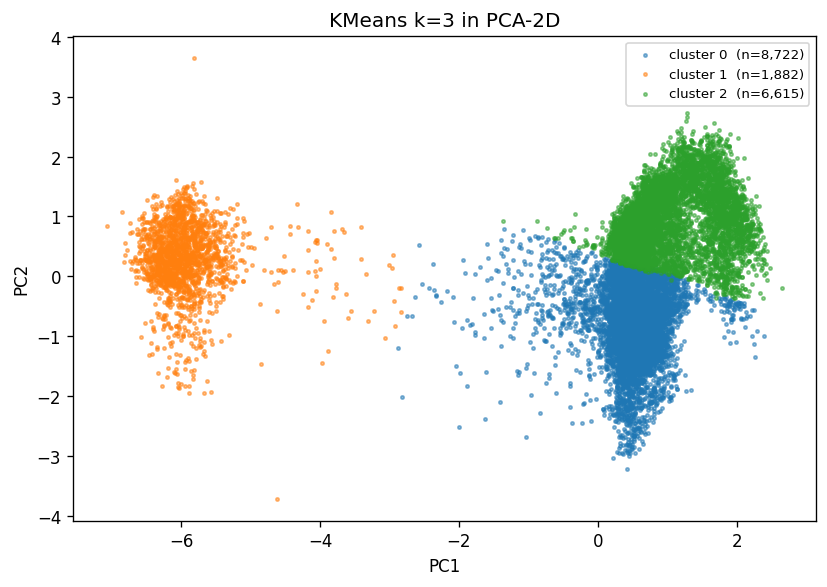

KMeans silhouette @ k=3: 0.275
Cluster sizes:
0    8722
1    1882
2    6615


In [4]:
labels_km, km, scaler_km = cluster_operating_conditions(X, n_clusters=best_k)
coords_2d = reduce_for_viz(X, scaler_km)

fig, ax = plt.subplots(figsize=(7, 5))
for lab in sorted(set(labels_km)):
    m = labels_km == lab
    ax.scatter(coords_2d[m,0], coords_2d[m,1], s=4, alpha=0.5,
               label=f'cluster {lab}  (n={m.sum():,})')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.set_title(f'KMeans k={best_k} in PCA-2D')
ax.legend(loc='best', fontsize=8)
plt.tight_layout(); plt.show()

print(f'KMeans silhouette @ k={best_k}: {silhouette_score(X, labels_km):.3f}')
print('Cluster sizes:')
print(pd.Series(labels_km).value_counts().sort_index().to_string())


## 4. HDBSCAN — variable-k cross-check (Q9)

**Takeaway:** HDBSCAN checks whether a density-based view sees the same structure or only a coarser version of it.


HDBSCAN builds a mutual-reachability MST and extracts clusters that persist across density thresholds.  Unlike KMeans it:

- Chooses the number of clusters itself (via `min_cluster_size`).
- Labels low-density points as **noise** (`-1`) instead of forcing them into a cluster.
- Does not assume convex clusters.

`min_cluster_size = 50` ≈ a 5-hour minimum episode at our cycle rate — below that we call it noise rather than a regime.  A low noise fraction (< 30 %) means density structure is genuinely present; a high noise fraction means feature space is too smooth for density-based clustering and KMeans is the better tool.

/Users/wrg/well-analysis/.venv/lib/python3.12/site-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


HDBSCAN found 2 clusters, noise fraction = 0.4 %


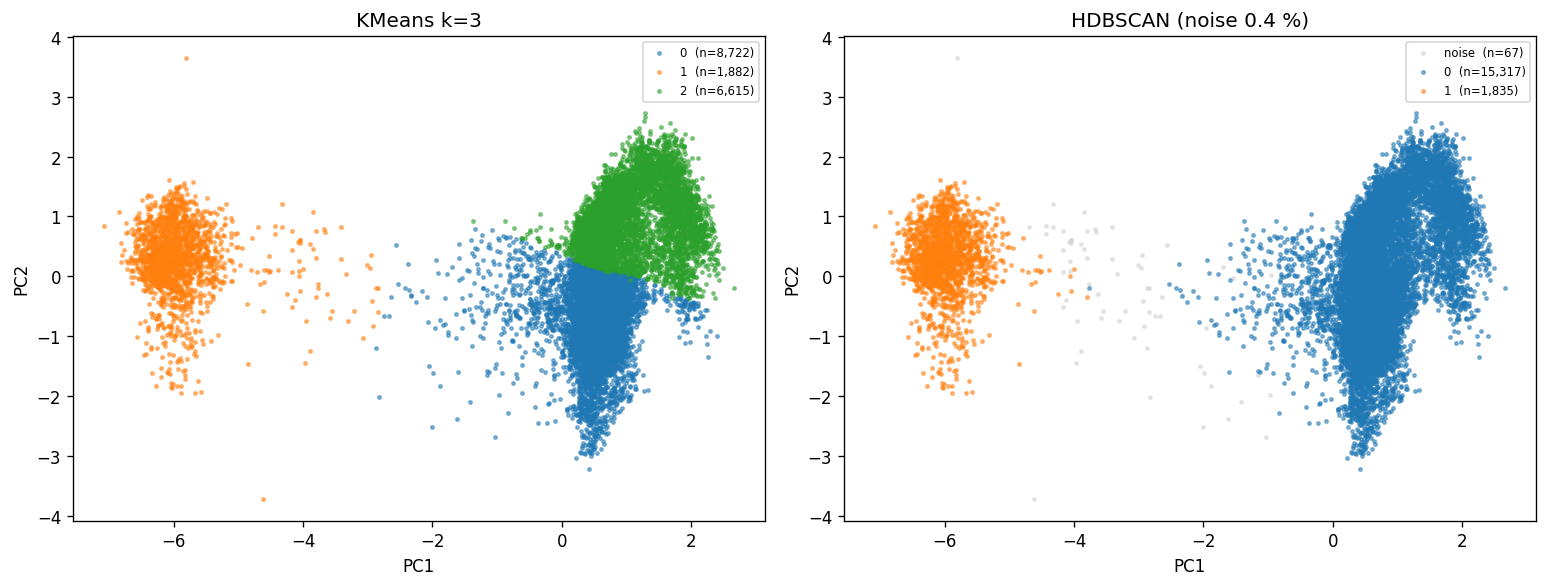

Adjusted Rand Index (non-noise rows): 0.290
ARI interpretation: 1.0 = perfect agreement, 0.0 = random.


In [5]:
labels_hd, hd, scaler_hd = cluster_with_hdbscan(X, min_cluster_size=50)
noise_frac = (labels_hd == -1).mean()
n_clusters_hd = labels_hd[labels_hd >= 0].max() + 1 if (labels_hd >= 0).any() else 0
print(f'HDBSCAN found {n_clusters_hd} clusters, noise fraction = {100*noise_frac:.1f} %')

# Visualise on the same PCA axes as KMeans (use KMeans scaler so they overlay)
coords_hd = reduce_for_viz(X, scaler_km)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
for ax, labs, title in [(ax1, labels_km, f'KMeans k={best_k}'),
                        (ax2, labels_hd, f'HDBSCAN (noise {100*noise_frac:.1f} %)')]:
    uniq = sorted(set(labs))
    for lab in uniq:
        m = labs == lab
        colour = 'lightgray' if lab == -1 else cm.tab10(lab % 10)
        ax.scatter(coords_hd[m,0], coords_hd[m,1], s=4, alpha=0.5, color=colour,
                   label=f'{lab if lab >= 0 else "noise"}  (n={m.sum():,})')
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); ax.set_title(title)
    ax.legend(loc='best', fontsize=7)
plt.tight_layout(); plt.show()

# Agreement: ARI excludes noise by convention — we use non-noise rows only
non_noise = labels_hd != -1
ari = adjusted_rand_score(labels_km[non_noise], labels_hd[non_noise])
print(f'Adjusted Rand Index (non-noise rows): {ari:.3f}')
print('ARI interpretation: 1.0 = perfect agreement, 0.0 = random.')


## 5. Naming the KMeans clusters — one median card each

**Takeaway:** medoid cards turn abstract cluster labels back into representative loop shapes.


For each KMeans cluster we compute the *medoid* (the card in that cluster whose feature vector is closest to the mean) and plot it against the typical card from the full trusted set.  The shape tells us what regime the cluster represents.

Labels are **assigned manually from shape inspection** — automated clustering does not give regime names, humans do.

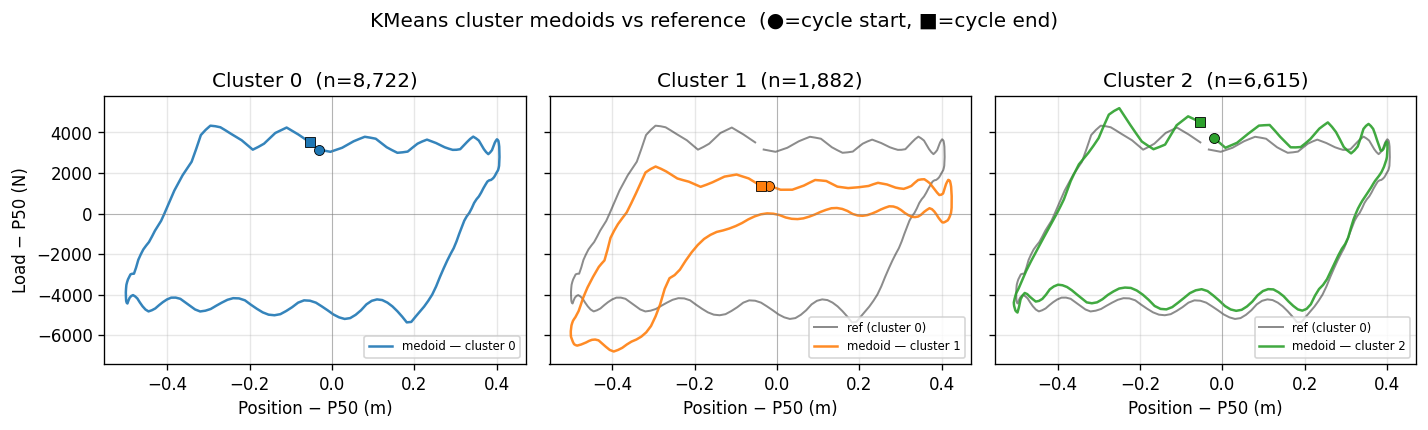

Cluster centroid means (original units):
 cluster  n_cards     area  p10_load  p90_load  asym_tilt  upstroke_heaviness  load_median
       0     8722 6102.196 10489.701 18951.067     -0.003               0.156    15288.451
       1     1882 2502.563 11115.533 18957.831     -0.142               0.089    17335.858
       2     6615 5920.881 10505.762 19190.839      0.010               0.161    15059.163


In [6]:
# Keep one real representative card (medoid) per cluster so the taxonomy stays physically interpretable.
cluster_sizes = pd.Series(labels_km).value_counts()
ref_cluster = int(cluster_sizes.idxmax())
idx_ref = medoid_index(X, labels_km, ref_cluster, scaler_km)
c_ref = trusted_cards[idx_ref]
p_ref = c_ref['pos'] - np.median(c_ref['pos'])
l_ref = c_ref['load'] - np.median(c_ref['load'])

n_clust = best_k
cols = 3
rows = (n_clust + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 3.5 * rows), sharex=True, sharey=True)
axes = np.atleast_2d(axes).flatten()
for k, ax in zip(range(n_clust), axes):
    idx = medoid_index(X, labels_km, k, scaler_km)
    c = trusted_cards[idx]
    p = c['pos'] - np.median(c['pos'])
    l = c['load'] - np.median(c['load'])
    colour = cm.tab10(k % 10)
    if k != ref_cluster:
        ax.plot(p_ref, l_ref, lw=1.2, color='black', alpha=0.45, label=f'ref (cluster {ref_cluster})')
    ax.plot(p, l, lw=1.5, color=colour, alpha=0.9, label=f'medoid — cluster {k}')
    ax.plot(p[0], l[0], 'o', color=colour, ms=6, mec='k', mew=0.5)
    ax.plot(p[-1], l[-1], 's', color=colour, ms=6, mec='k', mew=0.5)
    ax.set_title(f'Cluster {k}  (n={(labels_km==k).sum():,})')
    ax.legend(loc='lower right', fontsize=7)
    ax.axhline(0, color='gray', lw=0.3)
    ax.axvline(0, color='gray', lw=0.3)
    ax.grid(alpha=0.3)
for ax in axes[n_clust:]:
    ax.axis('off')
for ax in axes[-cols:]:
    ax.set_xlabel('Position − P50 (m)')
for ax in axes[::cols]:
    ax.set_ylabel('Load − P50 (N)')
plt.suptitle('KMeans cluster medoids vs reference  (●=cycle start, ■=cycle end)', y=1.01)
plt.tight_layout(); plt.show()

summary = summarize_cluster_feature_means(X, labels_km, list(FEATURE_NAMES))
print('Cluster centroid means (original units):')
print(summary.round(3).to_string(index=False))


## 6. Bridge back to nb04: are the era-specific references consistent with the Q9 taxonomy?

**Takeaway:** this bridge section checks whether nb04's era-specific comparison baselines are consistent with the independently learned Q9 taxonomy.


nb04 uses **two era-specific near-normal reference shapes** (pre- and post-
2020-12-31) as the black comparison curves in the Q8 anomaly gallery.  Those
references are not treated as physical ground truth; they are point-wise median
surface-card baselines built from trusted, low-anomaly cards within each era.

Here we validate those baselines against the Q9 clustering result in three
ways:

1. **Core-cluster mix.** For each era, take the inlier core used to build the
   nb04 reference (trusted cards in that era with IF score below the within-era
   P50) and ask which Q9 cluster those cards belong to.
2. **Shape distance to medoids.** Compare each era reference curve directly to
   the three KMeans medoids using the same channel-normalised curve-L2 idea.
3. **Direct visual overlay.** Plot era 0 and era 1 references against the same
   three medoids so we can see whether each reference looks like a near-normal
   regime rather than the anomaly medoid.

This is a **consistency check**, not proof that a reference is the “correct”
pump card.  The question is simply whether nb04's chosen comparison baselines
match the dominant near-normal regimes found independently here in Q9.

Inlier-core cluster mix (%):
  era 0: cluster 0 = 12.4, cluster 1 = 0.0, cluster 2 = 87.6
  era 1: cluster 0 = 93.0, cluster 1 = 0.0, cluster 2 = 7.0

All trusted-card cluster mix by era (%):
  era 0: cluster 0 = 9.3, cluster 1 = 1.9, cluster 2 = 88.8
  era 1: cluster 0 = 76.6, cluster 1 = 16.6, cluster 2 = 6.8

Curve distance table (lower = more similar):
           cluster 0  cluster 1  cluster 2
era 0 ref      1.068     10.376      1.346
era 1 ref      0.577     10.571      1.920

Nearest medoid by curve distance:
  era 0 ref -> cluster 0
  era 1 ref -> cluster 0


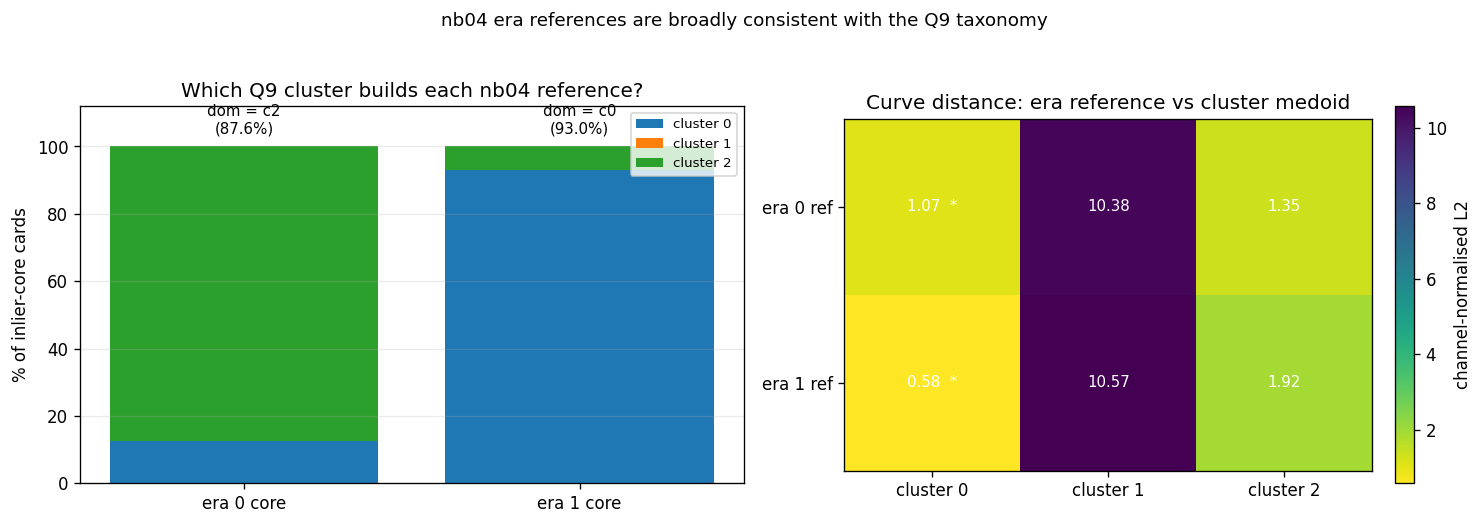

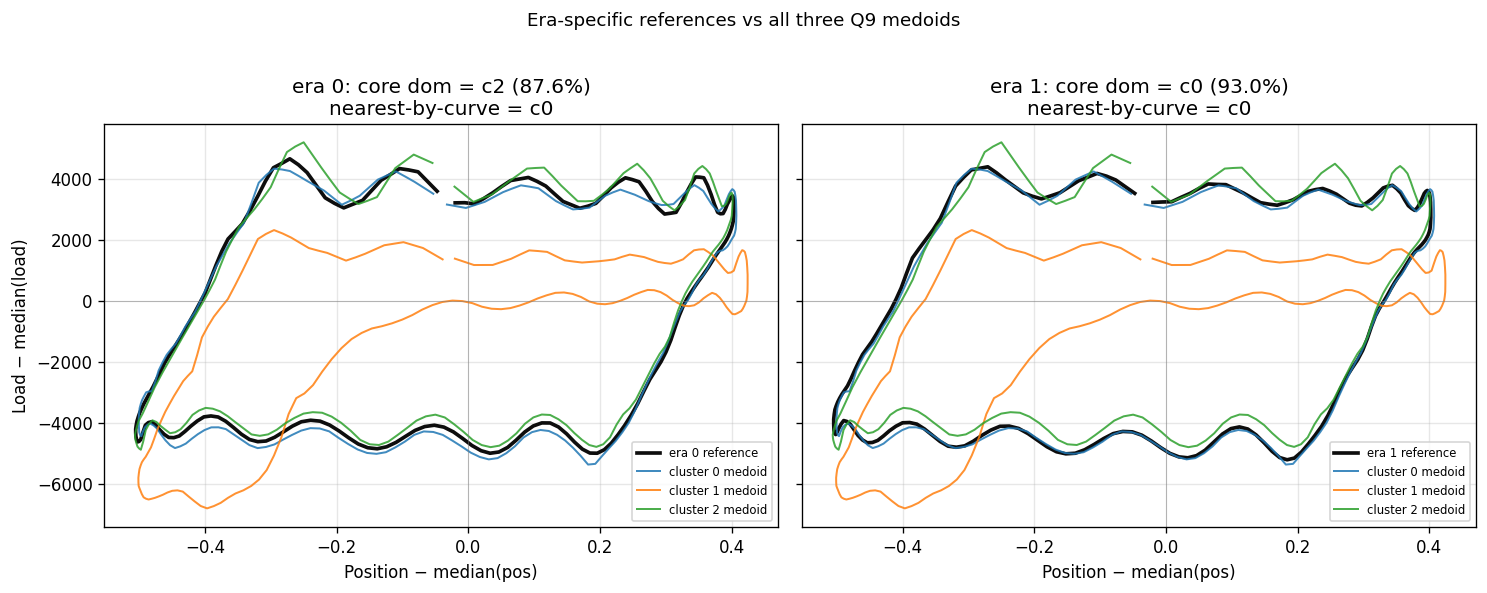


Interpretation:
- Era 1 is clean: its inlier core is overwhelmingly cluster 0 and the reference curve is also closest to cluster 0.
- Era 0 is mostly built from cluster 2, but the pointwise-median reference lies between the two near-normal medoids (0 and 2), not on the anomaly axis.
- Both era references are far from cluster 1, so the two-baseline strategy used in nb04 is consistent with the Q9 taxonomy.


In [7]:
# Rebuild the trusted-card frame used downstream in Q10 and recreate nb04's era-specific references.
dm_tr = build_trusted_cluster_frame(dm, trusted_idx, X, list(FEATURE_NAMES), labels_km, labels_hd)
ERA_SPLIT = pd.Timestamp('2020-12-31 23:59:59', tz=pd.to_datetime([c['t'] for c in all_cards]).tz)
bridge = validate_nb04_references_against_q9(
    all_cards=all_cards,
    dm=dm,
    trusted_mask=trusted_mask,
    trusted_idx=trusted_idx,
    trusted_cards=trusted_cards,
    features=X,
    labels_km=labels_km,
    scaler_km=scaler_km,
    era_split=ERA_SPLIT,
)
era_ref = bridge['era_ref']
core_mix = bridge['core_mix']
all_trusted_mix = bridge['all_trusted_mix']
medoids = bridge['medoids']
dist_tbl = bridge['dist_tbl']
nearest = bridge['nearest']

print('Inlier-core cluster mix (%):')
for e in [0, 1]:
    row = ', '.join([f'cluster {k} = {100*core_mix[e].loc[k]:.1f}' for k in [0, 1, 2]])
    print(f'  era {e}: {row}')
print()
print('All trusted-card cluster mix by era (%):')
for e in [0, 1]:
    row = ', '.join([f'cluster {k} = {100*all_trusted_mix[e].loc[k]:.1f}' for k in [0, 1, 2]])
    print(f'  era {e}: {row}')
print()
print('Curve distance table (lower = more similar):')
print(dist_tbl.round(3).to_string())
print()
print('Nearest medoid by curve distance:')
for idx, val in nearest.items():
    print(f'  {idx} -> {val}')

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2), gridspec_kw={'width_ratios': [1.15, 1]})
ax = axes[0]
cluster_cols = {0: cm.tab10(0), 1: cm.tab10(1), 2: cm.tab10(2)}
bottom = np.zeros(2)
for k in [0, 1, 2]:
    vals = np.array([100 * core_mix[e].loc[k] for e in [0, 1]])
    ax.bar([0, 1], vals, bottom=bottom, color=cluster_cols[k], label=f'cluster {k}')
    bottom += vals
for i, e in enumerate([0, 1]):
    dom = int(core_mix[e].idxmax())
    pct = 100 * core_mix[e].max()
    ax.text(i, 103, f'dom = c{dom}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=9)
ax.set_xticks([0, 1])
ax.set_xticklabels(['era 0 core', 'era 1 core'])
ax.set_ylim(0, 112)
ax.set_ylabel('% of inlier-core cards')
ax.set_title('Which Q9 cluster builds each nb04 reference?')
ax.legend(fontsize=8, loc='upper right')
ax.grid(axis='y', alpha=0.25)

ax = axes[1]
im = ax.imshow(dist_tbl.values, cmap='viridis_r')
ax.set_xticks(range(3)); ax.set_xticklabels(dist_tbl.columns)
ax.set_yticks(range(2)); ax.set_yticklabels(dist_tbl.index)
ax.set_title('Curve distance: era reference vs cluster medoid')
for i in range(dist_tbl.shape[0]):
    for j in range(dist_tbl.shape[1]):
        val = dist_tbl.values[i, j]
        mark = '  *' if nearest.iloc[i] == dist_tbl.columns[j] else ''
        ax.text(j, i, f'{val:.2f}{mark}', ha='center', va='center', color='white', fontsize=9)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='channel-normalised L2')
plt.suptitle('nb04 era references are broadly consistent with the Q9 taxonomy', y=1.03, fontsize=11)
plt.tight_layout(); plt.show()

fig2, axes2 = plt.subplots(1, 2, figsize=(12.5, 4.8), sharex=True, sharey=True)
for e, ax in enumerate(axes2):
    p_ref, l_ref = era_ref[e]
    ax.plot(p_ref, l_ref, color='black', lw=2.2, alpha=0.95, label=f'era {e} reference')
    for k in [0, 1, 2]:
        ax.plot(medoids[k]['pos'], medoids[k]['load'], color=cluster_cols[k], lw=1.2, alpha=0.85, label=f'cluster {k} medoid')
    ax.axhline(0, color='gray', lw=0.3); ax.axvline(0, color='gray', lw=0.3)
    ax.grid(alpha=0.3)
    ax.set_xlabel('Position − median(pos)')
    if e == 0:
        ax.set_ylabel('Load − median(load)')
    dom = int(core_mix[e].idxmax())
    dom_pct = 100 * core_mix[e].max()
    near = nearest.iloc[e].replace('cluster ', 'c')
    ax.set_title(f'era {e}: core dom = c{dom} ({dom_pct:.1f}%)\nnearest-by-curve = {near}')
    ax.legend(loc='lower right', fontsize=7)
plt.suptitle('Era-specific references vs all three Q9 medoids', y=1.02, fontsize=11)
plt.tight_layout(); plt.show()

print() 
print('Interpretation:')
print('- Era 1 is clean: its inlier core is overwhelmingly cluster 0 and the reference curve is also closest to cluster 0.')
print('- Era 0 is mostly built from cluster 2, but the pointwise-median reference lies between the two near-normal medoids (0 and 2), not on the anomaly axis.')
print('- Both era references are far from cluster 1, so the two-baseline strategy used in nb04 is consistent with the Q9 taxonomy.')


## 7. Regime timeline over 21 days (Q10)

**Takeaway:** the timeline shows when each regime dominates and whether there is a record-wide shift rather than isolated flicker.


Strip plot — one dot per card, colour by KMeans cluster, y-jittered by cluster id.  Background shading marks timer_on segments so we can visually assess whether regime changes align with controller cycles.

A regular pattern of mid-timer_on regime transitions would support the liquid-level-recovery hypothesis (early cycles rich, late cycles depleted).  A *lack* of such pattern is evidence that the pump operates in steady state.

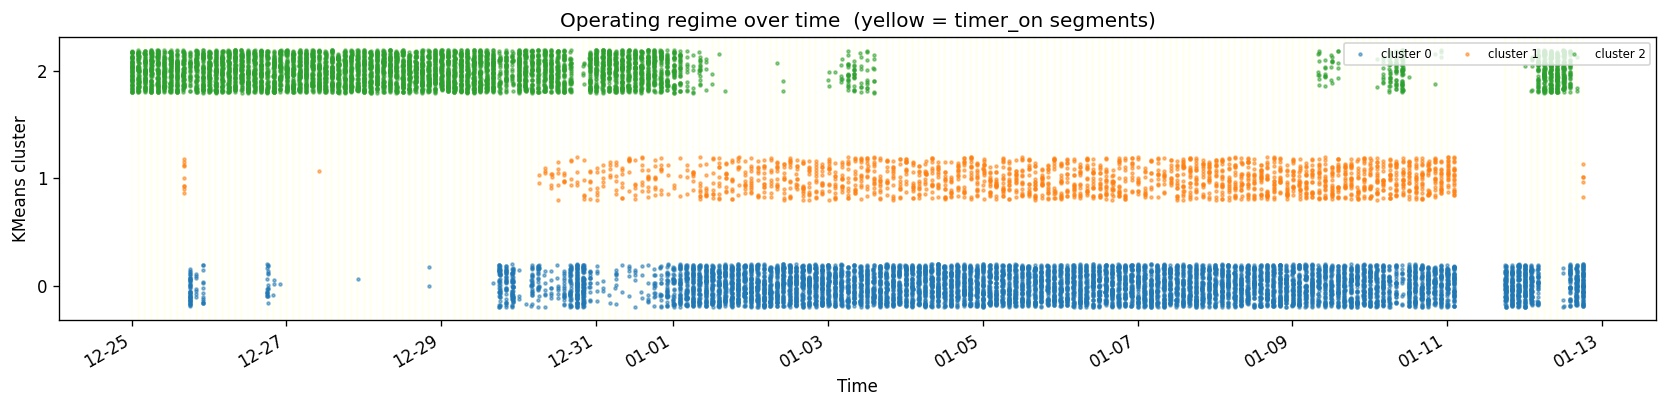

In [8]:
times_tr = pd.to_datetime(dm_tr['t'])

fig, ax = plt.subplots(figsize=(14, 3.5))
for _, row in timer_on.iterrows():
    ax.axvspan(row['start'], row['end'], color='lightyellow', alpha=0.4, zorder=0)
for lab in sorted(set(labels_km)):
    m = labels_km == lab
    ax.scatter(times_tr[m], np.full(m.sum(), lab) + np.random.uniform(-0.2, 0.2, m.sum()),
               s=3, alpha=0.5, color=cm.tab10(lab % 10), label=f'cluster {lab}')
ax.set_yticks(range(best_k))
ax.set_xlabel('Time'); ax.set_ylabel('KMeans cluster')
ax.set_title('Operating regime over time  (yellow = timer_on segments)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
ax.legend(loc='upper right', fontsize=7, ncol=best_k)
plt.tight_layout(); plt.show()


## 8. Episode detection and duration distribution (Q10)

**Takeaway:** Q10 reasons at the episode level, not just the single-card level, so persistence becomes visible.


An episode is a maximal run of consecutive cards in the same cluster, length ≥ 5 cards (≈ 1 minute of pumping).  Sub-5-card blips are discarded to focus on persistent regimes, not single-card flicker.

We report per-cluster: episode count, median / P95 duration (in cards), and total dwell fraction of the 21-day record.

467 episodes of length ≥ 5.

Episode statistics per regime:
        n_episodes  cards_total  median_len  p95_len  dwell_frac
regime                                                          
0              220         8117        32.5     69.0       0.471
1              137         1856        14.0     19.0       0.108
2              110         6015         9.5    354.6       0.349


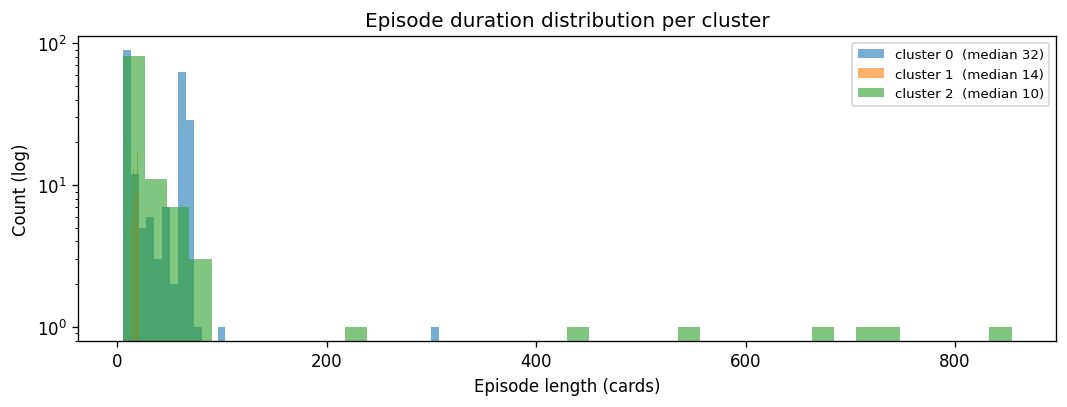

In [9]:
# Collapse card labels into episodes so Q10 reasons on persistent regimes rather than single-card flicker.
episodes = episodes_from_labels(labels_km, times_tr, min_len=5)
print(f'{len(episodes):,} episodes of length ≥ 5.')

stats = episode_statistics(episodes, n_cards_total=len(trusted_cards))
print() 
print('Episode statistics per regime:')
print(stats.round(3).to_string())

fig, ax = plt.subplots(figsize=(9, 3.5))
for lab in sorted(episodes['regime'].unique()):
    lens = episodes.loc[episodes['regime'] == lab, 'length']
    ax.hist(lens, bins=40, alpha=0.6, label=f'cluster {lab}  (median {lens.median():.0f})', color=cm.tab10(lab % 10))
ax.set_yscale('log')
ax.set_xlabel('Episode length (cards)')
ax.set_ylabel('Count (log)')
ax.set_title('Episode duration distribution per cluster')
ax.legend(loc='best', fontsize=8)
plt.tight_layout(); plt.show()


## 9. Episode-level transition matrix (Q10)

**Takeaway:** the transition matrix shows which regimes are sticky and which ones are quickly escaped.


`P(next_regime | prev_regime)` computed on consecutive episodes (not cards — cycle-level self-transitions would dominate).  Rows sum to 1.  Strong diagonal = regimes are sticky; off-diagonal mass shows which transitions are common.

Low row entropy means the next regime is predictable from the current one; high entropy means transitions are near-random.  We report both the matrix and per-row entropies.

Transition matrix (rows = prev, cols = next):
       0      1      2
0  0.377  0.550  0.073
1  0.875  0.000  0.125
2  0.164  0.145  0.691

Per-row entropy (bits; 0 = deterministic, log2(k) = uniform):
0    1.280
1    0.544
2    1.200


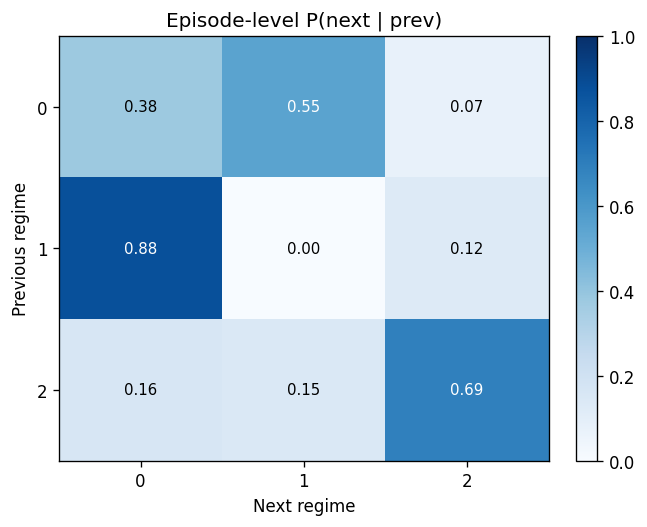

In [10]:
# Transition matrix + row entropy = how sticky each regime is and how predictable the next step looks.
P = transition_matrix(episodes)
print('Transition matrix (rows = prev, cols = next):')
print(P.round(3).to_string())

row_ent = transition_entropy_bits(P)
print() 
print('Per-row entropy (bits; 0 = deterministic, log2(k) = uniform):')
print(row_ent.round(3).to_string())

fig, ax = plt.subplots(figsize=(5.5, 4.5))
im = ax.imshow(P.values, cmap='Blues', vmin=0, vmax=1, aspect='auto')
for i in range(P.shape[0]):
    for j in range(P.shape[1]):
        ax.text(j, i, f'{P.iat[i,j]:.2f}', ha='center', va='center', color='white' if P.iat[i,j] > 0.5 else 'black', fontsize=9)
ax.set_xticks(range(len(P.columns))); ax.set_xticklabels(P.columns)
ax.set_yticks(range(len(P.index))); ax.set_yticklabels(P.index)
ax.set_xlabel('Next regime'); ax.set_ylabel('Previous regime')
ax.set_title('Episode-level P(next | prev)')
plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout(); plt.show()


## 10. Coupling with timer boundaries and hour-of-day (Q10)

**Takeaway:** timer-boundary and calendar diagnostics connect the learned regimes back to plausible physical mechanisms.


Two diagnostic questions:

1. **Timer-boundary effect**: does the regime mix in the first 5 minutes of each `timer_on` differ from the steady-state mix? If yes → liquid-level recovery hypothesis has support.
2. **Hour-of-day effect**: is any regime over-represented at particular hours?  Could reflect diurnal fluid-level variation, temperature, or controller schedule.

We also include a **day-of-record** check — is the regime mix drifting monotonically across the 21 days (progressive wear)?

How these diagnostics should be read physically:

- If the anomalous regime appears mainly **late within a timer_on round**, that is more consistent with **fluid depletion / declining fillage / fluid-pound-like behaviour** than with a start-up artefact.
- If the dominant near-normal shape changes **once across the record** (rather than oscillating hour by hour), that is more consistent with a **regime shift** than with isolated anomalies.
- If an anomalous episode tends to **fall back quickly** to one near-normal regime, that is more consistent with a **transient anomalous excursion** than with a stable long-lived operating state.

Regime mix -- first 5 min of timer_on vs rest:
            first 5 min  after 5 min
cluster_km                          
0                 0.621        0.454
2                 0.379        0.387
1                 0.000        0.159


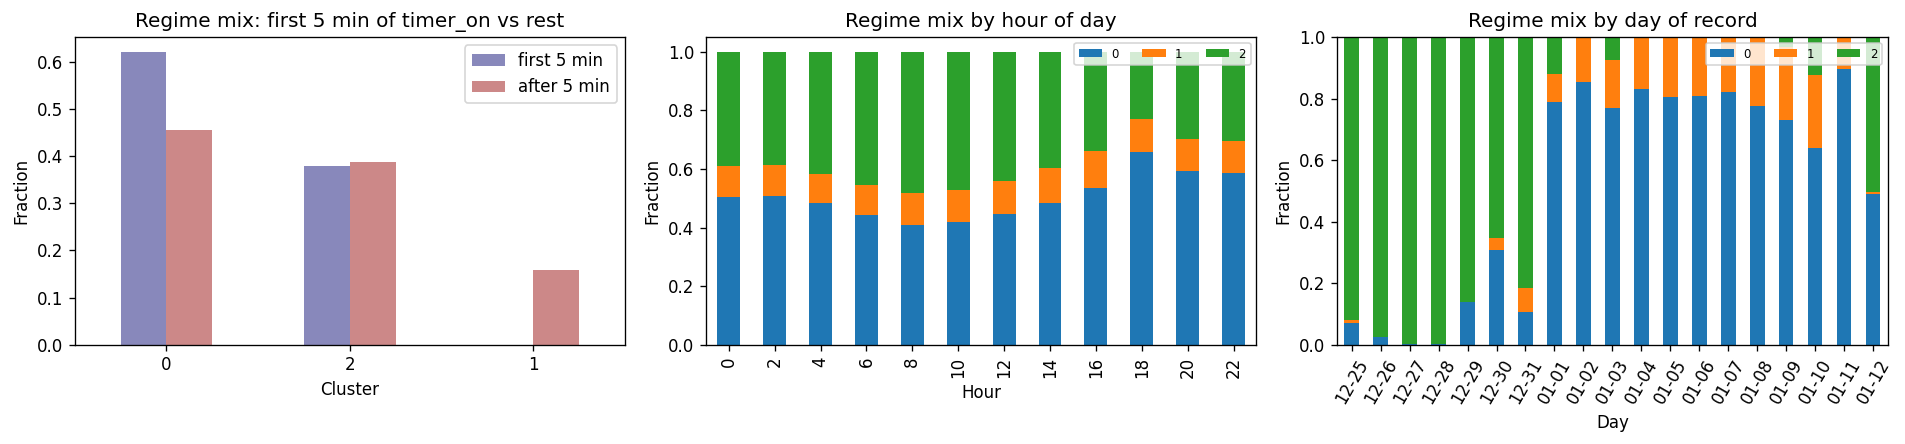

In [11]:
# These diagnostics connect the learned regimes back to controller timing and calendar structure.
diag = regime_mix_diagnostics(dm_tr, timer_on)
dm_tr = diag['dm_tr']
mix = diag['mix']
hour_mix = diag['hour_mix']
day_mix = diag['day_mix']

print('Regime mix -- first 5 min of timer_on vs rest:')
print(mix.round(3).to_string())

fig, axes = plt.subplots(1, 3, figsize=(16, 3.8))
mix.plot(kind='bar', ax=axes[0], color=['#88b', '#c88'], rot=0)
axes[0].set_title('Regime mix: first 5 min of timer_on vs rest')
axes[0].set_ylabel('Fraction'); axes[0].set_xlabel('Cluster')

hour_mix.plot(kind='bar', stacked=True, ax=axes[1], color=[cm.tab10(i) for i in hour_mix.columns])
axes[1].set_title('Regime mix by hour of day')
axes[1].set_ylabel('Fraction'); axes[1].set_xlabel('Hour')
axes[1].legend(loc='upper right', fontsize=7, ncol=best_k)

day_mix.plot(kind='bar', stacked=True, ax=axes[2], color=[cm.tab10(i) for i in day_mix.columns], rot=60)
axes[2].set_title('Regime mix by day of record')
axes[2].set_ylabel('Fraction'); axes[2].set_xlabel('Day')
axes[2].legend(loc='upper right', fontsize=7, ncol=best_k)

plt.tight_layout(); plt.show()


## 11. Bonus check — next-regime prediction as supporting evidence only

**Takeaway:** forecasting is bonus evidence only; the main Q10 answer is still time structure plus physical interpretation.


Q10 does **not** require forecasting.  The core task is to characterise the
**time structure** of the regimes and propose **physical hypotheses** for what
that structure may reflect downhole.  The small prediction exercise in this
section is therefore treated as a **bonus / supplementary check** only.

Why keep it at all?  Because if a simple short-memory model beats blind
baselines, that is extra evidence that the regime sequence contains real
transition structure rather than being a random alternation of labels.

The previous draft fit a 1st-order Markov chain on days 1–18 and tested on days
19–21.  Two flaws in that setup:

1. **Train/test straddles the 2020-12-31 regime shift** — training data is a mix of pre-shift and post-shift regimes; the test window is entirely post-shift.  Any Markov model fit this way must extrapolate across a non-stationarity.
2. **17 test episodes is too few** to distinguish real predictor lift from noise; a single wrong prediction moves accuracy by 6 pp.

**Fix in this section:**

- **Era-aware split**: train and test both come from era 1 (2021-01-01 onward).  We drop the pre-shift episodes for predictor evaluation.  They stay in §8–§10 for descriptive purposes.
- **Temporal 75/25 split** within era 1.  Bigger test window, bigger `N`.
- **Four baselines** compared head-to-head:
  1. *Uniform random over non-self regimes* — a weak random comparator; its realised accuracy is not fixed in finite samples (here it scores 0.333 on the test set).
  2. *Marginal frequency* — always predict the most frequent regime in train.
  3. *1st-order Markov* — argmax of `P(next | prev)`.
  4. *2nd-order Markov* — argmax of `P(next | prev_prev, prev)`; falls back to 1st-order when a (prev_prev, prev) pair has < 3 observations.

So the question here is narrow: **does the empirical transition structure beat a blind marginal-frequency guess on this well?**  Not whether we can build a production predictor — 21 days is too short for that — but whether there is exploitable short-memory transition structure at all.

### What we are NOT doing

- **Autoencoder / LSTM / transformer** — with ~300 era-1 episodes total, any deep model is firmly in overfit territory.  These tools would be appropriate on multi-year data from a fleet, not this single 21-day single-well run.
- **Predicting episode duration** (survival analysis) — out of scope for Q10.
- **Card-level next-cluster prediction** — would be 90 %+ persistence-dominated (cards within an episode are by construction same regime) and thus trivial.

Era-1 episodes available: 340  (from 2021-01-01 00:01:36.865876124+00:00 to 2021-01-12 18:14:57.865876124+00:00)
Split at 2021-01-09 10:00:00+00:00:  train = 253,  test = 87

1st-order transition matrix (train):
       0      1      2
0  0.313  0.660  0.027
1  1.000  0.000  0.000
2  0.375  0.125  0.500

2nd-order coverage: 6 / 7 pairs have >=3 observations.

Test-set predictions scored: N = 87
               predictor  accuracy  n_test
      uniform (non-self)     0.333      87
                marginal     0.575      87
              1st-Markov     0.575      87
2nd-Markov (w/ fallback)     0.655      87

Best: 2nd-Markov (w/ fallback) (acc = 0.655)

Confusion (rows normalised) for best predictor:
predicted     0     1     2
truth                      
0          0.74  0.22  0.04
1          0.41  0.45  0.14
2          0.33  0.00  0.67

5. Logistic regression on (prev_pair one-hot + log durations): acc = 0.529

All predictors:
                     predictor  accuracy  n_test
           

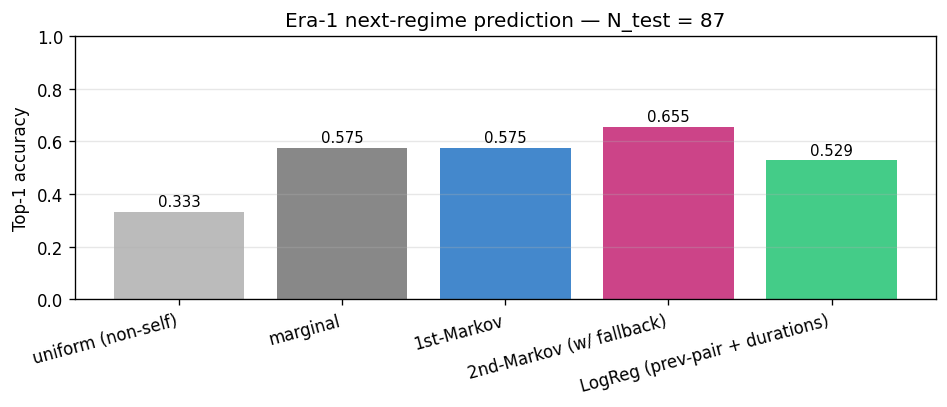

In [12]:
# Bonus only: a small forecasting check to confirm that the learned sequence has real short-memory structure.
bonus = evaluate_bonus_prediction(episodes, split_quantile=0.75)
ERA_SPLIT = bonus['era_split']
ep_era1 = bonus['ep_era1']
split_ts = bonus['split_ts']
train = bonus['train']
test = bonus['test']
P1 = bonus['p1']
results = bonus['results']
conf = bonus['best_confusion']

print(f'Era-1 episodes available: {len(ep_era1)}  (from {ep_era1["start"].min()} to {ep_era1["end"].max()})')
print(f'Split at {split_ts}:  train = {len(train)},  test = {len(test)}')
print() 
print('1st-order transition matrix (train):')
print(P1.round(3).to_string())
print() 
print(f'2nd-order coverage: {bonus["coverage"]} / {len(bonus["counts2"])} pairs have >=3 observations.')
print() 
print(f'Test-set predictions scored: N = {len(bonus["truths"])}')
print(results.iloc[:4].to_string(index=False, float_format='%.3f'))
print() 
print(f'Best: {bonus["best_name"]} (acc = {results["accuracy"].max():.3f})')
print() 
print('Confusion (rows normalised) for best predictor:')
print(conf.round(2).to_string())
print() 
print(f'5. Logistic regression on (prev_pair one-hot + log durations): acc = {bonus["acc_lr"]:.3f}')
print() 
print('All predictors:')
print(results.to_string(index=False, float_format='%.3f'))

fig, ax = plt.subplots(figsize=(8, 3.5))
colors = ['#bbb', '#888', '#4488cc', '#cc4488', '#44cc88']
bars = ax.bar(results['predictor'], results['accuracy'], color=colors[:len(results)])
for b, a in zip(bars, results['accuracy']):
    ax.text(b.get_x() + b.get_width() / 2, a + 0.01, f'{a:.3f}', ha='center', va='bottom', fontsize=9)
ax.set_ylim(0, 1.0)
ax.set_ylabel('Top-1 accuracy')
ax.set_title(f'Era-1 next-regime prediction — N_test = {len(bonus["truths"])}')
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=15, ha='right')
plt.tight_layout(); plt.show()


## 12. Honest caveats and summary

**Takeaway:** the final section gathers the Q9 taxonomy, the Q10 time structure, and the downhole-condition hypotheses in one place.


**What this notebook establishes (concrete numbers from the run above):**

- KMeans at **k = 3** is the **chosen useful taxonomy** for Q9/Q10 within `k ∈ {3..6}` (silhouette 0.275 at k = 3).  Raw silhouette still favours **k = 2**, so the data also supports a coarser two-group reading.
- HDBSCAN finds **2 clusters** with only 0.4 % noise — density structure exists, but it is less granular than KMeans imposes.  ARI(KMeans, HDBSCAN) = 0.29 — modest agreement, consistent with HDBSCAN collapsing KMeans clusters 0 + 2 into one broader near-normal basin.
- The **bridge back to nb04 is clean**: era 1's inlier core is **93.0 % cluster 0** and its reference curve is also closest to cluster 0; era 0's inlier core is **87.6 % cluster 2**, while its pointwise-median reference lies in the near-normal **0/2 corridor** rather than on the anomaly axis.  Both era references are far from **cluster 1**.
- Episode dwell fractions: cluster 0 = 47 %, cluster 2 = 35 %, cluster 1 = 11 %.  Row entropies of the transition matrix (0: 1.28, 1: 0.54, 2: 1.20 bits) show cluster 1 is **predictably escaped** (87.5 % of cluster-1 episodes transition to cluster 0), while clusters 0 and 2 flip between themselves more stochastically.
- **Three Q10 interpretations worth flagging:**
  1. *Late-within-round anomaly growth*: cluster 1 accounts for 0.0 % of the first 5 minutes of timer_on and 15.9 % of the rest.  This makes the anomalous regime look more like **fluid depletion / declining fillage / fluid-pound-like behaviour** than a start-up artefact.
  2. *Mid-record baseline replacement*: the day-of-record plot shows cluster 2 dominating 12-25 … 12-30 (≈100 % mix), then cluster 0 dominating 01-01 onward.  That pattern is more naturally read as a **regime shift** — possibly operational, sensor-related, or slowly mechanical — than as scattered isolated anomalies.
  3. *Transient anomalous excursions*: cluster 1 is not a stable long-lived state; it is relatively small (11 % dwell) and strongly routes back to cluster 0.  That makes it look more like a **temporary excursion away from the post-shift near-normal state** than a permanent operating mode.

**Bonus prediction check (§11):**

Restricting both train and test to era 1 (post-12-31), with a 75/25 temporal split (train N = 253, test N = 87), and benchmarking five predictors:

| predictor | accuracy |
|---|---|
| uniform (non-self) | 0.333 |
| marginal (majority) | 0.575 |
| 1st-order Markov | 0.575 |
| **2nd-order Markov (with 1st-order fallback)** | **0.655** |
| LogReg (prev-pair one-hot + log durations) | 0.529 |

This section is **bonus evidence**, not the core answer to Q10.  Its role is simply to show that the regime sequence has some exploitable short-memory structure:

- **2nd-order context is the sweet spot**: +8 pp over the marginal baseline (0.655 vs 0.575) on N = 87, lift = +0.08.
- **1st-order Markov adds no signal** over the marginal.
- **LogReg loses to 2nd-Markov** at this sample size; sparse counts beat richer parameters here.
- **What this does not mean**: 0.655 on 87 episodes is a working-prototype number, not a production guarantee.  The 8 pp lift would need to be re-tested on additional months of data.

**What this notebook does *not* establish:**

- A cluster label is **not** a validated fault diagnosis.  Each cluster is a hypothesis about a recurring surface-card shape; confirmation requires downhole data or Gibbs wave-equation inversion.
- We did not try a 3rd-order Markov, semi-Markov (duration-aware), or HMM.  3rd-order would require ≥ 27 prev-triple cells with adequate counts — at 253 episodes most cells would have < 5 observations, and the 2nd-Markov fallback rate would dominate.  Semi-Markov / HMM are reasonable next steps but exceed Q10's remit.
- `StandardScaler` gives every feature equal weight.  Different weightings could yield different clusterings.  Unweighted is the most defensible default without a domain-specific loss function.
- 21 days is short, and with a mid-record regime shift it effectively splits into two ≈ 10-day eras.  Transition statistics estimated across the full record mix two operational eras and should be read with that caveat — which is exactly why §11 restricts to era 1.

**Where this connects back:**

- Q8 = curated anomaly gallery referenced against two era-specific near-normal baselines.
- Q9 (this notebook) = unsupervised regime taxonomy.  Three KMeans clusters are a useful working partition: two near-normal variants that alternate dominance by calendar era, and one anomaly basin.
- Q10 = time structure plus physical hypotheses: the anomalous regime emerges late within rounds, the near-normal baseline changes once across the record, and the anomaly state behaves more like a transient excursion than a permanent state.
- The prediction section is **bonus support** for that story, not the main deliverable.